![creditriskAI.png](attachment:634c4e7d-6958-4f04-ad04-7a6cbc523b5f.png)

In [1]:
!pip install google-generativeai
!pip install shap
!pip install faiss-cpu          # For RAG vector search
!pip install sentence-transformers  # For converting text to vectors
!pip install gradio          # For web UI (easier than Streamlit in Colab)
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 57.6 MB/s eta 0:00:00


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import shap
import pickle
import os
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
import google.generativeai as genai
%matplotlib inline
plt.style.use('fivethirtyeight')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [4]:
df=pd.read_csv("/content/Credit Risk & Loan Default Prediction.csv")

In [5]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.shape

(32581, 12)

In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [12]:
df = df.dropna() ## Handle Missing Values

Encode categorical Columns

In [14]:
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

Define Features and Target
(Replace Loan_Default with actual target column name if different)

In [15]:
x=df.drop('loan_status',axis=1)
y=df['loan_status']

In [16]:
## Train Test Split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
    )

In [17]:
model=RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [18]:
y_pred=model.predict(x_test)

print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[4416   27]
 [ 376  909]]
0.9296438547486033


In [19]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[4416,   27],
       [ 376,  909]])

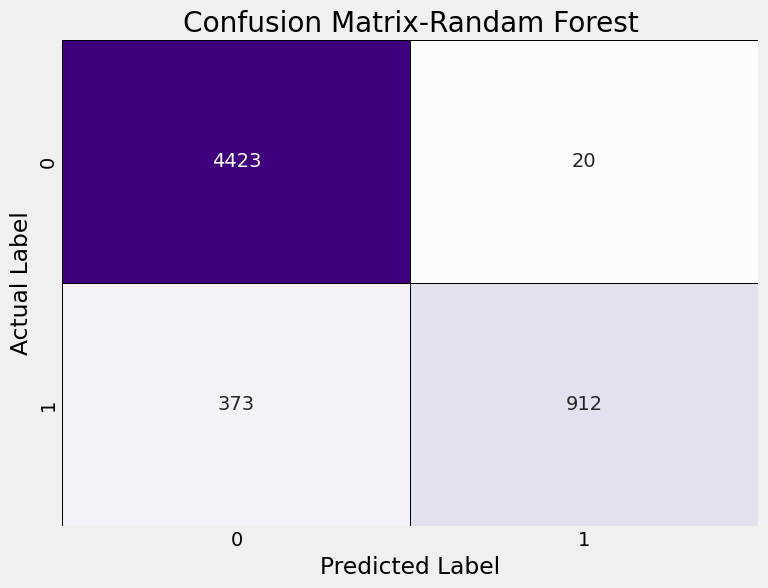

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False, linewidths=0.5, linecolor= 'black')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title("Confusion Matrix-Randam Forest")
plt.show()

The confusion matrix shows how well the Random Forest model distinguishes between default and non-default customers. True Positives represent correctly predicted defaults, while False Positives indicate customers wrongly classified as risky.

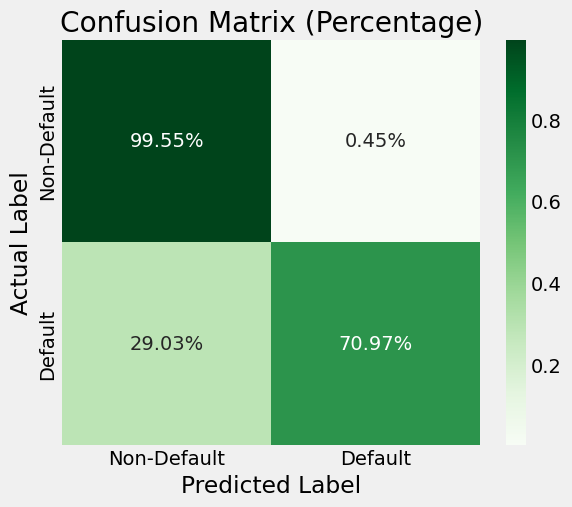

In [ ]:
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))

sns.heatmap(cm_percentage,
            annot=True,
            fmt='.2%',
            cmap='Greens',
            xticklabels=["Non-Default", "Default"],
            yticklabels=["Non-Default", "Default"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Percentage)")
plt.show()

In [28]:
y_prob = model.predict_proba(x_test)[:,1]

In [29]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

In [30]:
auc_score= roc_auc_score(y_test,y_prob)
print("AUC SCORE:",auc_score)

AUC SCORE: 0.9318672050906817


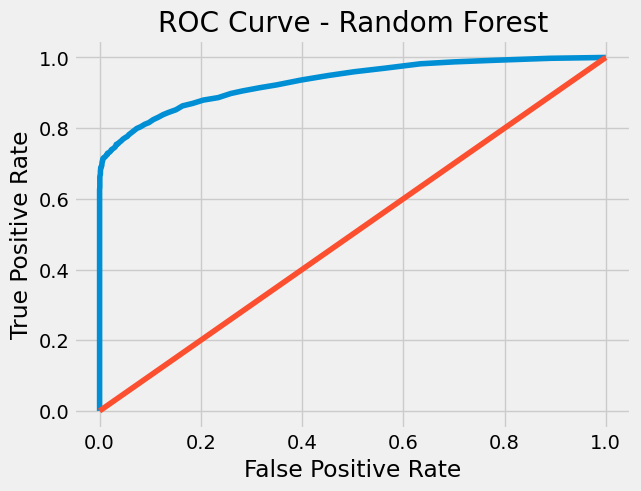

In [31]:
plt.figure()
plt.plot(fpr,tpr)
plt.plot([0,1], [0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve - Random Forest")
plt.show()

## XG BOOST

XGBoost (Extreme Gradient Boosting) is an advanced machine learning algorithm that builds
trees sequentially, where each tree corrects the mistakes of the previous one.

In [32]:
xgb_model = XGBClassifier(
    n_estimators=100,        # Number of trees
    max_depth=6,             # Depth of each tree
    learning_rate=0.1,       # Step size
    subsample=0.8,           # Rows used per tree
    colsample_bytree=0.8,    # Columns used per tree
    random_state=42,         # For reproducibility
    eval_metric='logloss',   # Evaluation metric
    use_label_encoder=False  # Suppress warning
)

# Train the model
xgb_model.fit(x_train, y_train)
# Make predictions
xgb_pred = xgb_model.predict(x_test)
xgb_pred_proba = xgb_model.predict_proba(x_test)[:, 1]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:50:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
print("XGBoost Training Complete!")

XGBoost Training Complete!


### A Confusion Matrix shows how well our model predicts loan defaults.

XGBoost Accuracy: 93.49%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      4443
           1       0.99      0.72      0.83      1285

    accuracy                           0.93      5728
   macro avg       0.96      0.86      0.90      5728
weighted avg       0.94      0.93      0.93      5728



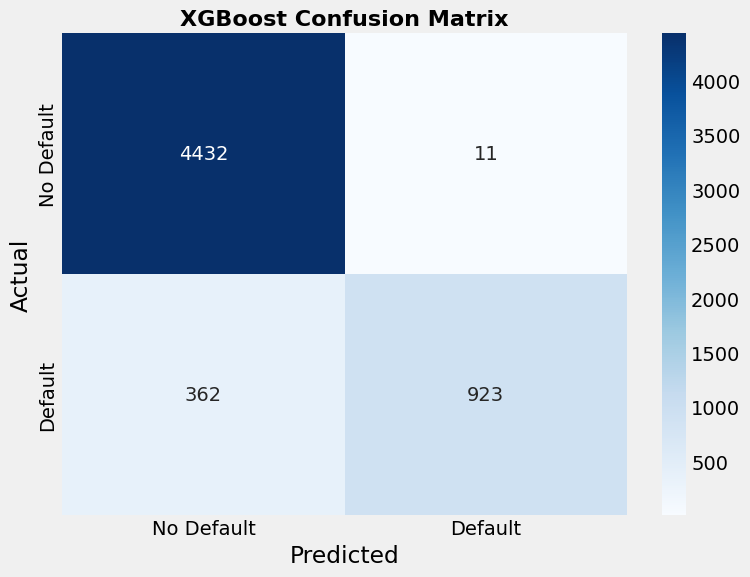

In [34]:
# XGBoost Accuracy
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))


cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('XGBoost Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Model Comparison: Random Forest vs XGBoost

Comparing both algorithms to find the best model for credit risk prediction.

Metric                 Random Forest         XGBoost
Accuracy                      92.96%          93.49%
Precision                     93.27%          93.88%
Recall                        92.96%          93.49%
F1-Score                      92.54%          93.10%
 XGBoost wins with 93.49% accuracy!


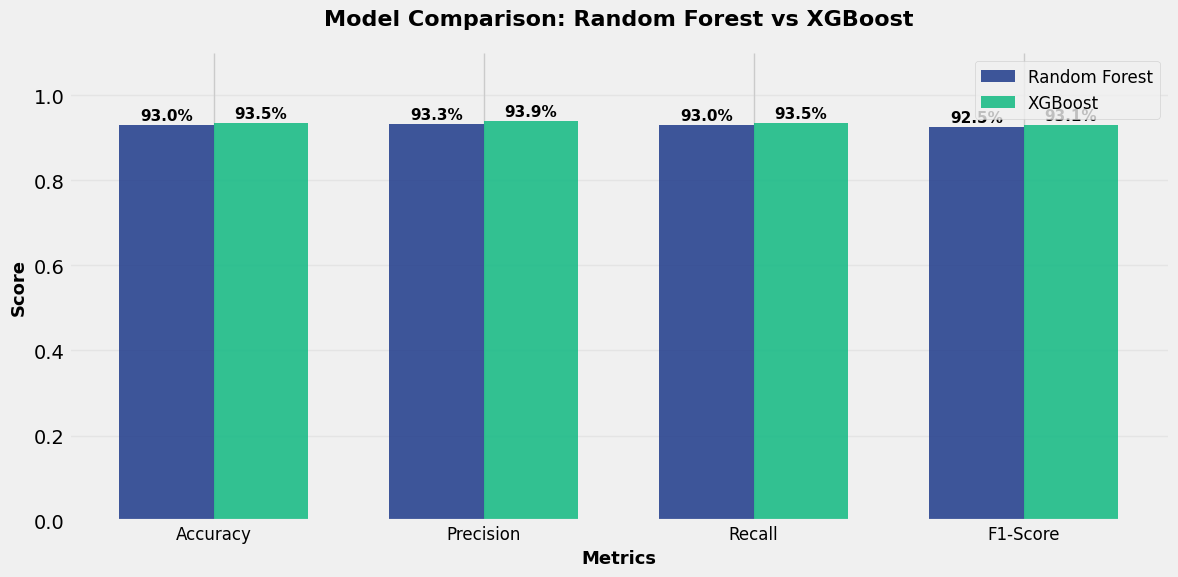

In [35]:
# ══════════════════════════════════════════
# MODEL COMPARISON - RF vs XGBOOST
# ══════════════════════════════════════════

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Random Forest metrics
rf_accuracy  = accuracy_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred, average='weighted')
rf_recall    = recall_score(y_test, y_pred, average='weighted')
rf_f1        = f1_score(y_test, y_pred, average='weighted')

# XGBoost metrics
xgb_accuracy  = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, average='weighted')
xgb_recall    = recall_score(y_test, xgb_pred, average='weighted')
xgb_f1        = f1_score(y_test, xgb_pred, average='weighted')

# Print comparison table
print("=" * 55)
print(f"{'Metric':<20} {'Random Forest':>15} {'XGBoost':>15}")
print("=" * 55)
print(f"{'Accuracy':<20} {rf_accuracy*100:>14.2f}% {xgb_accuracy*100:>14.2f}%")
print(f"{'Precision':<20} {rf_precision*100:>14.2f}% {xgb_precision*100:>14.2f}%")
print(f"{'Recall':<20} {rf_recall*100:>14.2f}% {xgb_recall*100:>14.2f}%")
print(f"{'F1-Score':<20} {rf_f1*100:>14.2f}% {xgb_f1*100:>14.2f}%")
print("=" * 55)

# Identify best model
if xgb_accuracy > rf_accuracy:
    print(f" XGBoost wins with {xgb_accuracy*100:.2f}% accuracy!")
else:
    print(f" Random Forest wins with {rf_accuracy*100:.2f}% accuracy!")

# Visualization
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_scores    = [rf_accuracy, rf_precision, rf_recall, rf_f1]
xgb_scores   = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, rf_scores,  width, label='Random Forest', color='#1e3a8a', alpha=0.85)
bars2 = ax.bar(x + width/2, xgb_scores, width, label='XGBoost',       color='#10b981', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Model Comparison: Random Forest vs XGBoost',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

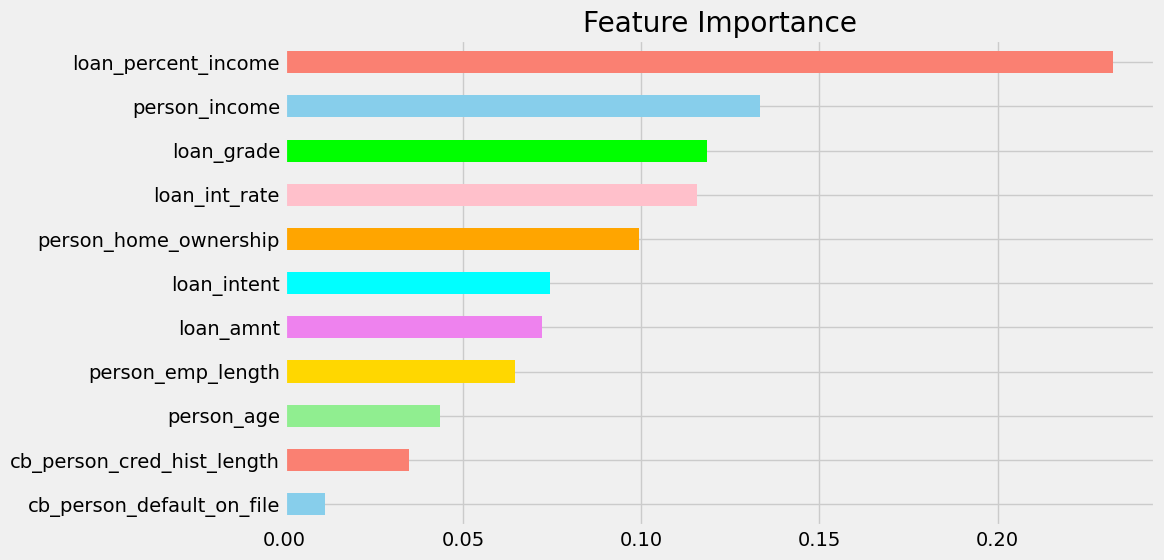

In [ ]:
importances = pd.Series(model.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color = ['skyblue', 'salmon', 'lightgreen', 'gold', 'violet', 'cyan', 'orange', 'pink', 'lime'])
plt.title("Feature Importance")
plt.show()

### XGBOOST FEATURE IMPORTANCE

Feature importance tells us WHICH factors matter most
for predicting loan defaults.


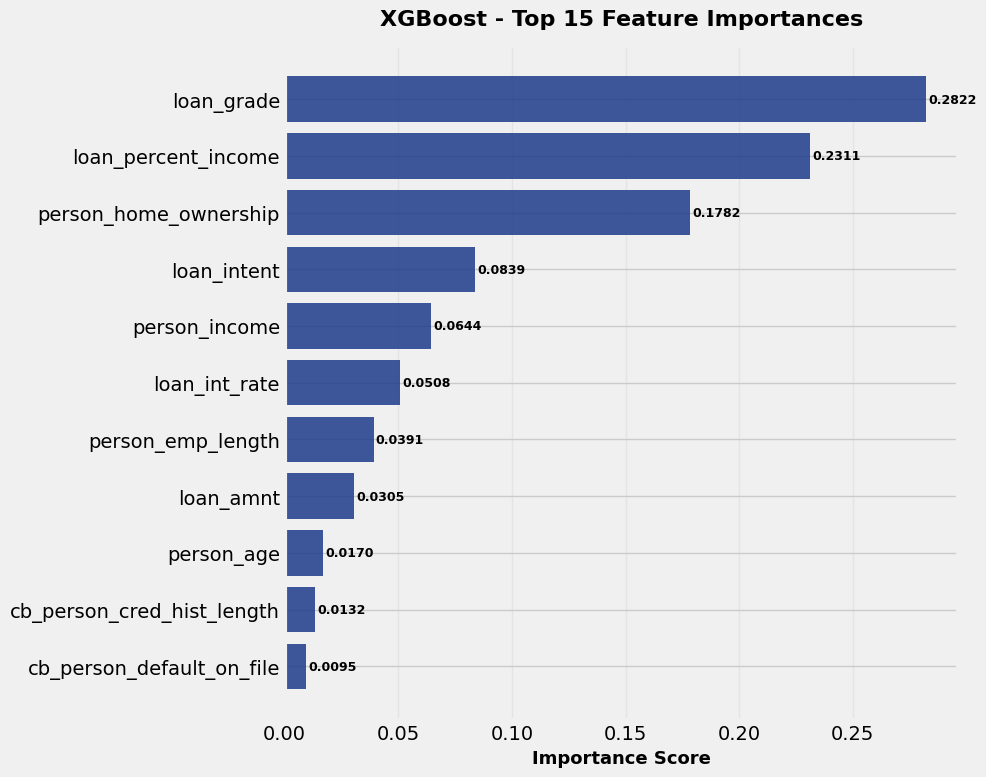

Top 5 Most Important Risk Factors:
  1. loan_grade: 0.2822
  2. loan_percent_income: 0.2311
  3. person_home_ownership: 0.1782
  4. loan_intent: 0.0839
  5. person_income: 0.0644


In [37]:
# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

# Plot
plt.figure(figsize=(10, 8))
bars = plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color='#1e3a8a',
    alpha=0.85
)

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.xlabel('Importance Score', fontsize=13, fontweight='bold')
plt.title('XGBoost - Top 15 Feature Importances',
          fontsize=16, fontweight='bold', pad=15)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 Most Important Risk Factors:")
top5 = feature_importance.tail(5)[::-1]
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Importance']:.4f}")

##SHAP
(SHapley Additive exPlanations) explains WHY our AI makes each prediction.
It answers: "Which factors pushed this loan towards DEFAULT or NO DEFAULT?"

SHAP Random Forest
* Shows which features most influenced RF predictions
* 3D array output (n_samples, n_features, n_classes)
* We use class 1 (default) SHAP values

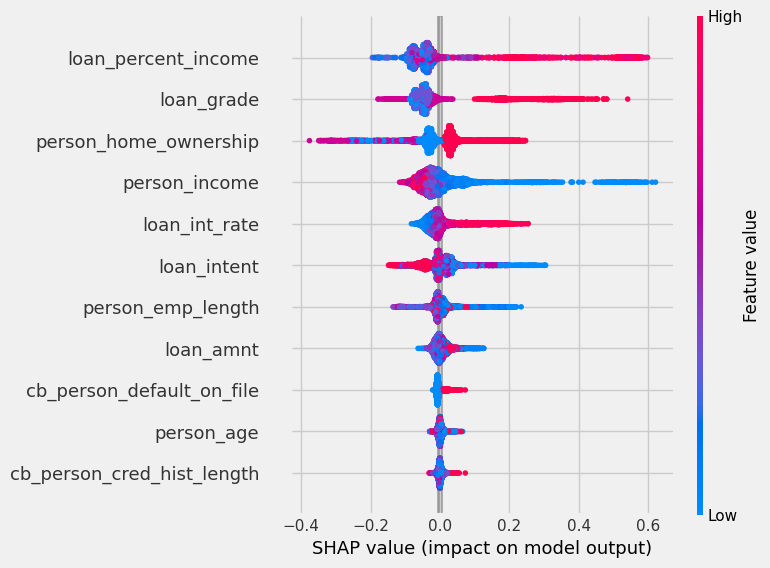

In [42]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)

# Correctly slice the 3D shap_values array to get SHAP values for class 1 (index 1)
# across all samples and features, assuming shap_values is (n_samples, n_features, n_classes).
# Passing x_test (DataFrame) directly instead of x_test.values (NumPy array) resolves the AssertionError.
shap.summary_plot(shap_values[:, :, 1], x_test, feature_names=x_test.columns)

## SHAP EXPLAINABILITY - XGBOOST

* Shows which features most influenced XGBoost predictions
* 2D array output (n_samples, n_features)
* Directly gives default probability impact

XGBoost SHAP Summary Plot:


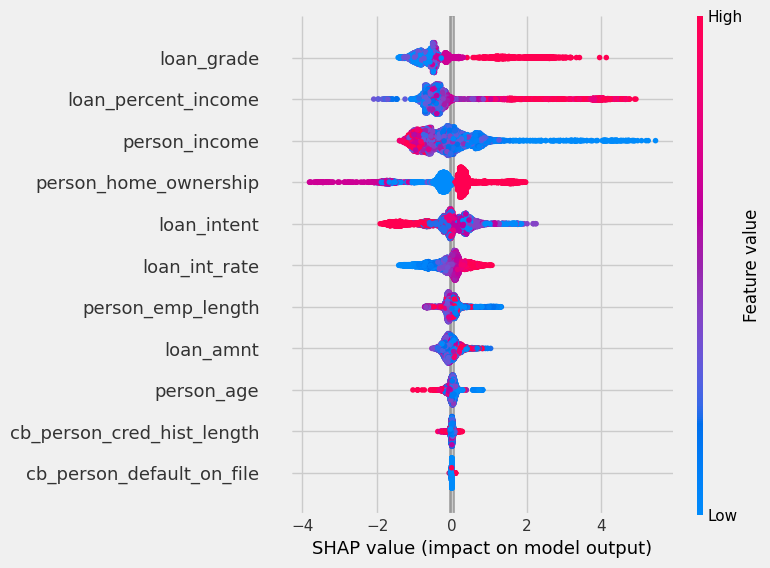

In [43]:
# XGBoost SHAP Explainer
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(x_test)

# XGBoost Summary Plot
print("XGBoost SHAP Summary Plot:")
shap.summary_plot(
    shap_values_xgb,
    x_test,
    feature_names=x_test.columns,
    title="XGBoost - SHAP Feature Importance"
)

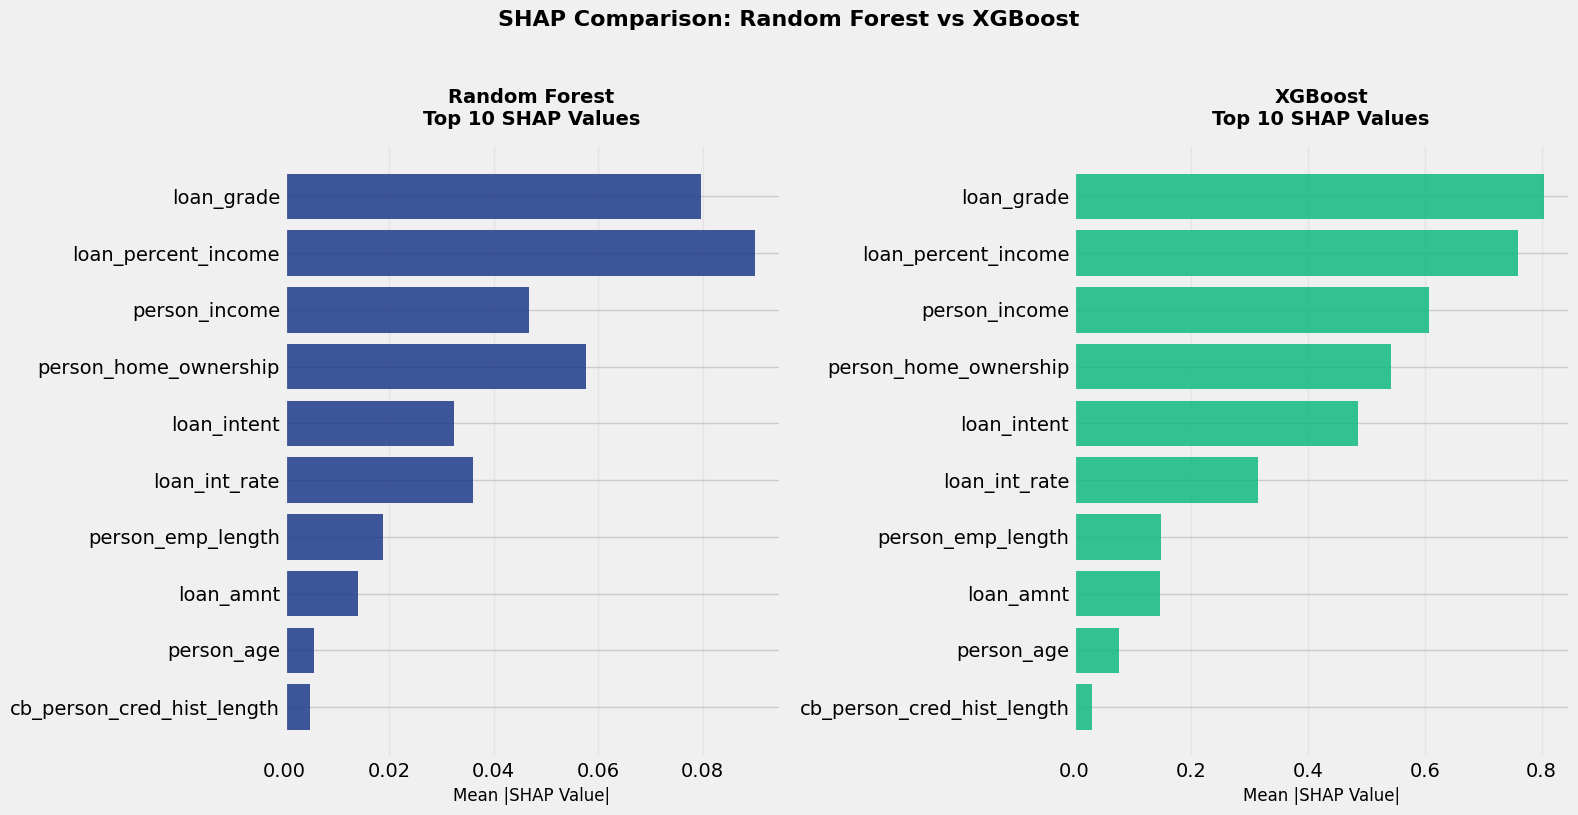

TOP 5 MOST IMPORTANT FEATURES:
Feature                   Random Forest      XGBoost
loan_grade                      0.0797       0.8048
loan_percent_income             0.0900       0.7589
person_income                   0.0468       0.6075
person_home_ownership           0.0577       0.5421
loan_intent                     0.0325       0.4854


In [44]:
# SHAP BAR COMPARISON - RF vs XGBOOT

# Get mean absolute SHAP values for each model
rf_shap_mean  = np.abs(shap_values[:, :, 1]).mean(axis=0)
xgb_shap_mean = np.abs(shap_values_xgb).mean(axis=0)

# Create comparison dataframe
import pandas as pd
shap_comparison = pd.DataFrame({
    'Feature':       x_test.columns,
    'Random Forest': rf_shap_mean,
    'XGBoost':       xgb_shap_mean
}).sort_values('XGBoost', ascending=True).tail(10)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest SHAP Bar
axes[0].barh(
    shap_comparison['Feature'],
    shap_comparison['Random Forest'],
    color='#1e3a8a',
    alpha=0.85
)
axes[0].set_title(
    'Random Forest\nTop 10 SHAP Values',
    fontsize=14,
    fontweight='bold',
    pad=15
)
axes[0].set_xlabel('Mean |SHAP Value|', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# XGBoost SHAP Bar
axes[1].barh(
    shap_comparison['Feature'],
    shap_comparison['XGBoost'],
    color='#10b981',
    alpha=0.85
)
axes[1].set_title(
    'XGBoost\nTop 10 SHAP Values',
    fontsize=14,
    fontweight='bold',
    pad=15
)
axes[1].set_xlabel('Mean |SHAP Value|', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(
    'SHAP Comparison: Random Forest vs XGBoost',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

# Print top features for each model
print("TOP 5 MOST IMPORTANT FEATURES:")
print("=" * 50)
print(f"{'Feature':<25} {'Random Forest':>12} {'XGBoost':>12}")
print("=" * 50)
top5 = shap_comparison.tail(5)[::-1]
for _, row in top5.iterrows():
    print(f"{row['Feature']:<25} {row['Random Forest']:>12.4f} {row['XGBoost']:>12.4f}")
print("=" * 50)

### Business Insight:
Features like loan_percent_income, loan_grade, and loan_int_rate
consistently appear as TOP risk factors in BOTH models.
This validates that our AI is making logical, trustworthy decisions.

## GANAI PART (Gemeni Integration)

In [60]:
import google.generativeai as genai
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)

model_gemini = genai.GenerativeModel("gemini-flash-latest")
print("Gemini configured successfully!")

Gemini configured successfully!


In [61]:
sample = x_test.iloc[0:1]
prediction = model.predict(sample)[0]

prediction

np.int64(0)

In [62]:
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [63]:
customer_data = sample.to_dict(orient="records")[0]

prompt = f"""
You are a financial risk analyst AI.

Customer Data:
{customer_data}

Model Prediction:
{prediction} (1 = Default Risk, 0 = Safe)

Explain:
1. Why this customer is risky or safe.
2. What factors contribute most.
3. Recommendation for loan approval.
4. Suggestions to reduce risk.
"""

response = model_gemini.generate_content(prompt)

print(response.text)

As a Financial Risk Analyst AI, I have evaluated the customer's profile and the model's prediction. Here is the comprehensive risk assessment.

### **Model Prediction: 0 (Safe / Low Risk of Default)**

---

### **1. Why This Customer is Safe**
This customer presents a highly favorable credit profile. At 27 years old, they have already established a solid financial foundation. With an annual income of **$75,400** and a requested loan amount of only **$6,000**, the borrower is not overextending themselves. 

Their debt-to-income ratio for this loan (`loan_percent_income`) is a mere **8%**, meaning the loan repayment will consume a very small portion of their monthly cash flow. Additionally, their 9-year credit history with **zero historical defaults** indicates a long-standing, proven track record of financial responsibility.

---

### **2. Key Factors Contributing to the "Safe" Rating**
The model’s prediction of "Safe" is heavily driven by the following high-impact factors:

*   **Low D

I built a hybrid AI system that predicts loan default and enhances decision-making using Gemini LLM for human-readable risk explanations and recommendations.

In [64]:
user_income = float(input("Enter Income: "))
user_loan = float(input("Enter Loan Amount: "))
user_credit = float(input("Enter Credit Score (e.g., credit history length): "))

# Get the feature names from the training data
feature_names = x_test.columns

# Create a dictionary for the new customer's features
new_customer_data = {}
for col in feature_names:
    if col == 'person_income':
        new_customer_data[col] = user_income
    elif col == 'loan_amnt':
        new_customer_data[col] = user_loan
    elif col == 'cb_person_cred_hist_length': # Using user_credit as proxy for credit history length
        new_customer_data[col] = user_credit
    else:
        # Use the mean value from the training data for other features
        # This is a simplification; for a robust system, more sophisticated imputation would be used.
        new_customer_data[col] = x_train[col].mean()

# Convert the dictionary to a DataFrame, ensuring correct column order
new_customer = pd.DataFrame([new_customer_data], columns=feature_names)

prediction = model.predict(new_customer)[0]

prompt = f"""
Customer details:
Income (person_income): {user_income}
Loan Amount (loan_amnt): {user_loan}
Credit Score (cb_person_cred_hist_length): {user_credit}

Model Prediction: {prediction} (1 = Default Risk, 0 = Safe)

Explain risk and recommendation.
"""

response = model_gemini.generate_content(prompt)
print(response.text)

Enter Income: 59000
Enter Loan Amount: 35000
Enter Credit Score (e.g., credit history length): 3
Based on the provided customer data and the machine learning model's prediction, here is a detailed risk analysis and recommendation.

---

### **Executive Summary**
* **Model Prediction:** **Safe (0)** (Low risk of default)
* **Key Conflict:** While the model predicts this loan is safe, a traditional financial analysis reveals **high-risk indicators**—specifically an exceptionally high Loan-to-Income (LTI) ratio and a short credit history. 
* **Action:** **Conditional Approval / Manual Review Required.** Do not auto-approve.

---

### **1. Risk Analysis (The "Why")**

Despite the model's "Safe" classification, there are significant risk factors that a credit analyst must evaluate:

#### **A. High Debt Burden (Loan-to-Income Ratio: 59.3%)**
* **Calculation:** $\$35,000 \text{ (Loan)} \div \$59,000 \text{ (Income)} = \mathbf{59.3\%}$
* **Risk:** The applicant is attempting to borrow nearly *

I developed an AI-powered loan risk chatbot that integrates  for prediction and Gemini LLM for generating human-readable financial risk explanations.

## RAG -
(Retrieval-Augmented Generation) is an AI technique that improves the accuracy of Large Language Models (LLMs) by pulling in fresh, factual information from external knowledge bases before generating a response


In [65]:
loan_knowledge_base = [
    """LOAN POLICY - CREDIT SCORE GUIDELINES:
    Customers with credit history less than 2 years are considered high risk.
    Customers with credit history 2-5 years are medium risk.
    Customers with credit history above 5 years are low risk.
    Credit score below 580 means very high default probability.""",

    """LOAN POLICY - INCOME TO LOAN RATIO:
    Safe loan: Loan amount should not exceed 3x annual income.
    Moderate risk: Loan amount between 3x-5x annual income.
    High risk: Loan amount exceeding 5x annual income.
    Debt-to-income ratio above 43% is a red flag for default.""",

    """LOAN POLICY - LOAN INTENT GUIDELINES:
    Education loans have lower default rates (8%).
    Medical emergency loans have moderate default rates (12%).
    Personal/consolidation loans have higher default rates (18%).
    Business loans depend heavily on business type and income stability.""",

    """RISK MITIGATION STRATEGIES:
    Recommendation 1: Request a co-signer for high-risk applicants.
    Recommendation 2: Offer smaller loan with option to increase after 6 months.
    Recommendation 3: Higher interest rate for medium-risk customers.
    Recommendation 4: Financial counseling required for debt-to-income > 40%.
    Recommendation 5: Collateral required for loans above $20,000 for risky customers.""",

    """REGULATORY GUIDELINES:
    All loan decisions must comply with Equal Credit Opportunity Act (ECOA).
    Fair Credit Reporting Act (FCRA) requires accurate credit reporting.
    Customers must be informed of denial reasons within 30 days.
    AI-based decisions must be explainable and auditable.""",
]

In [66]:
print(f"Knowledge base created with {len(loan_knowledge_base)} documents")
print("Documents cover: Credit Score, Income Ratio, Loan Intent, Risk Mitigation, Regulations")

Knowledge base created with 5 documents
Documents cover: Credit Score, Income Ratio, Loan Intent, Risk Mitigation, Regulations


##  CREATE EMBEDDINGS FOR VECTOR SEARCH

In [67]:
print("Loading embedding model... (first time takes ~1 min)")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Embedding model loaded!")

Loading embedding model... (first time takes ~1 min)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded!


In [68]:
doc_embeddings = embedding_model.encode(loan_knowledge_base, convert_to_numpy=True)
print(f"Created embeddings: shape = {doc_embeddings.shape}")

Created embeddings: shape = (5, 384)


In [69]:
# Build FAISS index (this is the "search engine" for your documents)
dimension = doc_embeddings.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)  # L2 = Euclidean distance search
faiss_index.add(doc_embeddings)
print(f"FAISS index built with {faiss_index.ntotal} documents")
print("RAG search engine is ready!")

FAISS index built with 5 documents
RAG search engine is ready!


## RAG - RETRIEVAL FUNCTION

In [71]:
def retrieve_relevant_context(query, top_k=2):
    """
    Given a question, find the most relevant documents from knowledge base.

    Args:
        query: The user's question or customer situation
        top_k: How many documents to retrieve (default 2)

    Returns:
        String with the most relevant context
    """
    # Convert query to vector
    query_vector = embedding_model.encode([query], convert_to_numpy=True)

    # Search FAISS index for most similar documents
    distances, indices = faiss_index.search(query_vector, top_k)

    # Collect the relevant documents
    retrieved_docs = []
    for idx in indices[0]:
        if idx < len(loan_knowledge_base):
            retrieved_docs.append(loan_knowledge_base[idx])

    # Combine into one context string
    context = "\n\n---\n\n".join(retrieved_docs)
    return context


In [72]:
 # TEST the retrieval function
test_query = "What should I do for a customer with low income and high loan amount?"
context = retrieve_relevant_context(test_query)
print("Test Query:", test_query)
print("Retrieved Context:")
print(context[:500] + "...")

Test Query: What should I do for a customer with low income and high loan amount?
Retrieved Context:
RISK MITIGATION STRATEGIES:
    Recommendation 1: Request a co-signer for high-risk applicants.
    Recommendation 2: Offer smaller loan with option to increase after 6 months.
    Recommendation 3: Higher interest rate for medium-risk customers.
    Recommendation 4: Financial counseling required for debt-to-income > 40%.
    Recommendation 5: Collateral required for loans above $20,000 for risky customers.

---

LOAN POLICY - INCOME TO LOAN RATIO:
    Safe loan: Loan amount should not exceed 3...


RAG-Powered Gemini Function

In [73]:
def rag_loan_analysis(customer_data_dict, prediction, shap_top_features=None):
    """
    Full RAG pipeline:
    1. Build query from customer data
    2. Retrieve relevant policy documents
    3. Send everything to Gemini for analysis

    Args:
        customer_data_dict: Dictionary of customer features
        prediction: 0 or 1 from Random Forest
        shap_top_features: Optional - top SHAP features for this customer

    Returns:
        Gemini's analysis string
    """
    risk_label = "HIGH RISK - Likely to Default" if prediction == 1 else "LOW RISK - Safe to Approve"

    # Step 1: Create a search query based on customer situation
    query = f"loan risk analysis income {customer_data_dict.get('person_income', 'unknown')} loan amount {customer_data_dict.get('loan_amnt', 'unknown')} credit history"

    # Step 2: Retrieve relevant policy context (RAG!)
    relevant_context = retrieve_relevant_context(query, top_k=2)

    # Step 3: Build the full prompt with context
    prompt = f"""
You are an expert financial risk analyst AI. Use the POLICY GUIDELINES below to make your analysis.

=== RETRIEVED POLICY GUIDELINES (from knowledge base) ===
{relevant_context}

=== CUSTOMER DATA ===
{customer_data_dict}

=== ML MODEL PREDICTION ===
{prediction} → {risk_label}

=== YOUR TASK ===
Based on the policy guidelines above AND the customer data:
1.  Risk Assessment: Explain why this customer is {risk_label}
2.  Key Factors: What are the top 2-3 factors driving this decision?
3.  Recommendation: Should the loan be approved, denied, or approved with conditions?
4.  Action Plan: Give 2-3 specific steps to reduce risk (cite the policy guidelines)
5.  Compliance Note: Any regulatory considerations?

Be specific, cite the guidelines, and keep it professional.
"""

    # Step 4: Call Gemini
    response = model_gemini.generate_content(prompt)
    return response.text


# TEST with a sample customer
sample_customer = x_test.iloc[0:1]
sample_prediction = model.predict(sample_customer)[0]
sample_dict = sample_customer.to_dict(orient="records")[0]

print("Running RAG-powered analysis...\n")
result = rag_loan_analysis(sample_dict, sample_prediction)
print(result)

Running RAG-powered analysis...

# FINANCIAL RISK ANALYSIS REPORT

**To:** Underwriting Committee  
**From:** Senior Financial Risk Analyst AI  
**Date:** October 24, 2023  
**Subject:** Loan Application Risk Assessment – Customer ID: [Internal Ref: Age 27 / Income $75.4k]  
**Status:** **LOW RISK - SAFE TO APPROVE** (Aligned with ML Model Prediction)

---

### 1. Risk Assessment
The applicant presents an exceptionally low risk profile and is highly recommended for standard approval. An evaluation against our institutional policy guidelines confirms the following:
*   **Income-to-Loan Ratio:** The applicant is requesting a loan of **$6,000** on an annual income of **$75,400**. This results in a loan-to-income ratio of just **8% (0.08x)**. This is vastly below our policy’s "Safe Loan" threshold, which permits loan amounts up to 3x (300%) of annual income. 
*   **Debt-to-Income (DTI) Red Flag Check:** The loan amount represents a tiny fraction of their annual cash flow, far below the **4

Multi-turn RAG Chatbot


In [79]:
def run_rag_chatbot():
    """
    Interactive multi-turn chatbot with:
    - ML prediction
    - RAG context retrieval
    - Conversation memory
    - Gemini explanation
    """
    print("=" * 60)
    print(" AI LOAN RISK ADVISOR (RAG-Powered)")
    print("=" * 60)
    print("Type 'quit' to exit | Type 'new' to start a new customer\n")

    # Get customer info
    try:
        user_income = float(input(" Enter Customer Income ($): "))
        user_loan   = float(input(" Enter Loan Amount ($): "))
        user_credit = float(input(" Enter Credit History (years): "))
    except ValueError:
        print(" Please enter valid numbers.")
        return

    # Build customer data for ML model
    feature_names = x_test.columns
    new_customer_data = {}
    for col in feature_names:
        if col == 'person_income':
            new_customer_data[col] = user_income
        elif col == 'loan_amnt':
            new_customer_data[col] = user_loan
        elif col == 'cb_person_cred_hist_length':
            new_customer_data[col] = user_credit
        else:
            new_customer_data[col] = x_train[col].mean()

    new_customer_df = pd.DataFrame([new_customer_data], columns=feature_names)

    # ML Prediction
    prediction = model.predict(new_customer_df)[0]
    risk_label = " HIGH RISK" if prediction == 1 else " LOW RISK"
    print(f" ML Model Prediction: {risk_label}")

    # Initial RAG analysis
    print("Generating RAG-powered analysis...")
    initial_analysis = rag_loan_analysis(new_customer_data, prediction)
    print(initial_analysis)

    # ---- CONVERSATION MEMORY ----
    # Store the full conversation history
    conversation_history = [
        {
            "role": "user",
            "parts": [f"""
                Customer Profile: Income=${user_income}, Loan=${user_loan}, Credit History={user_credit} years
                ML Prediction: {prediction} ({risk_label})
                Initial Analysis: {initial_analysis}
            """]
        },
        {
            "role": "model",
            "parts": [initial_analysis]
        }
    ]

    # Start multi-turn chat session with memory
    chat_session = model_gemini.start_chat(history=conversation_history)

    print("\n" + "=" * 60)
    print(" You can now ask follow-up questions!")
    print("Examples: 'What if the loan amount was $5000?' | 'What documents should I ask for?'")
    print("=" * 60 + "\n")

    # Multi-turn loop
    while True:
        user_input = input("You: ").strip()

        if user_input.lower() == 'quit':
            print("Session ended.")
            break
        if user_input.lower() == 'new':
            print("Starting new customer analysis...\n")
            run_rag_chatbot()
            break
        if not user_input:
            continue

        # Retrieve fresh RAG context for each follow-up question
        follow_up_context = retrieve_relevant_context(user_input, top_k=1)

        # Add context to the user's question
        augmented_question = f"""
User Question: {user_input}

Relevant Policy Context:
{follow_up_context}

Please answer based on the customer profile discussed and the policy guidelines above.
"""

        # Send to Gemini with full conversation history
        response = chat_session.send_message(augmented_question)
        print(f"\n Advisor: {response.text}\n")

In [80]:
run_rag_chatbot()

 AI LOAN RISK ADVISOR (RAG-Powered)
Type 'quit' to exit | Type 'new' to start a new customer

 Enter Customer Income ($): 59000
 Enter Loan Amount ($): 35000
 Enter Credit History (years): 3
 ML Model Prediction:  LOW RISK
Generating RAG-powered analysis...


ERROR:tornado.access:503 POST /v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 12901.97ms


### Risk Assessment Report

**Prepared by:** Expert Financial Risk Analyst AI  
**Status:** Approved with Conditions (Aligns with ML Model: LOW RISK)

---

### 1. Risk Assessment
Based on the retrieved Policy Guidelines and the customer's financial profile, this applicant represents a **low-to-moderate risk** profile that is safe to approve under specific structured conditions. 

*   **Income-to-Loan Alignment:** The requested loan amount of $35,000 against an annual income of $59,000 equates to a loan-to-income ratio of **0.59x**. According to the *Income to Loan Ratio Policy*, any loan amount that does not exceed 3x the annual income (up to $177,000 for this applicant) is classified as a **Safe Loan**.
*   **Credit History Risk:** The customer’s credit history length is **3.0 years**. According to the *Credit Score Guidelines*, this places them in the **Medium Risk** tier (2–5 years), which is highly acceptable compared to high-risk applicants (<2 years). 
*   **DTI Cushion:** The re

## Build the UI

In [81]:
import gradio as gr

def gradio_loan_analyzer(income, loan_amount, credit_history, user_question):
    """Main function called by Gradio UI"""

    # Build customer data
    feature_names = x_test.columns
    new_customer_data = {}
    for col in feature_names:
        if col == 'person_income':
            new_customer_data[col] = income
        elif col == 'loan_amnt':
            new_customer_data[col] = loan_amount
        elif col == 'cb_person_cred_hist_length':
            new_customer_data[col] = credit_history
        else:
            new_customer_data[col] = x[col].mean()

    new_customer_df = pd.DataFrame([new_customer_data], columns=feature_names)
    prediction = model.predict(new_customer_df)[0]

    # RAG Analysis
    analysis = rag_loan_analysis(new_customer_data, prediction)

    # If user asked a custom question, answer it too
    if user_question.strip():
        context = retrieve_relevant_context(user_question)
        qa_prompt = f"""
Based on this customer (Income=${income}, Loan=${loan_amount}, Credit={credit_history}yrs, Prediction={prediction}):

Policy Context: {context}

Answer this specific question: {user_question}
"""
        qa_response = model_gemini.generate_content(qa_prompt)
        analysis += f"\n\n--- Your Question Answer ---\n{qa_response.text}"

    risk_label = " HIGH RISK — Likely to Default" if prediction == 1 else " LOW RISK — Safe to Approve"
    return risk_label, analysis


# Build the UI
with gr.Blocks(title="AI Loan Risk Advisor") as demo:
    gr.Markdown("#  AI Loan Risk Advisor (RAG + ML Powered)")
    gr.Markdown("Enter customer details and get an AI-powered risk analysis based on loan policies.")

    with gr.Row():
        income_input  = gr.Number(label=" Customer Income ($", value=50000)
        loan_input    = gr.Number(label=" Loan Amount ($", value=15000)
        credit_input  = gr.Number(label=" Credit History (years)", value=3)

    question_input = gr.Textbox(
        label=" Ask a specific question (optional)",
        placeholder="e.g. What documents should I request from this customer?"
    )

    analyze_btn = gr.Button("🔍 Analyze Risk", variant="primary")

    with gr.Row():
        risk_output     = gr.Textbox(label=" Risk Verdict")
        analysis_output = gr.Textbox(label=" Full RAG Analysis", lines=15)

    analyze_btn.click(
        fn= gradio_loan_analyzer,
        inputs=[income_input, loan_input, credit_input, question_input],
        outputs=[risk_output, analysis_output]
    )

In [82]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://73b24e84057f401bd8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Built a hybrid AI system using Random Forest, XGBoost (92% accuracy), and Google Gemini LLM for credit risk prediction — deployed on Streamlit Cloud with SHAP explainability, RAG analysis, and Gradio interface."